# Regression

So far, we have been dealing with models that aim to predict categorical variables, such as kNN and Decision Trees. However, for continuous variables, we need to utilize a different set of models.

Regression analysis aims to find a mapping function `f` between a set of inputs (features) `X` and a continuous output variabel `Y`.

![](https://res.cloudinary.com/practicaldev/image/fetch/s--c4Lfzdwy--/c_limit%2Cf_auto%2Cfl_progressive%2Cq_auto%2Cw_880/https://thepracticaldev.s3.amazonaws.com/i/mjshszqx4fj22hs12vfn.png)

## Linear Regression

A statistical model that that examines the linear relationship between two (simple linear regression) or more (multiple linear regression) variables.

Linear regression performs the task to predict a **dependent variable** value `y` based on given **independent variable(s)** `x`. The relationship between `y` and `x` is represented by a linear equation.

$y \, = \, m_1*x_1 \, + ... + \, m_n*x_n \, + \, b$

![](https://faculty.elgin.edu/dkernler/statistics/ch04/images/slope-intercept.gif)

### Simple Linear Regression

Now, let's have an example on simple linear regression where the relationship between two continuous variables, `y` and `x` will be examined.

In [ ]:
from google.colab import drive
drive.mount('./drive', force_remount=True)

# drive path 
path_prefix = "./drive/My Drive"

Mounted at ./drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# to disable warning outputs
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

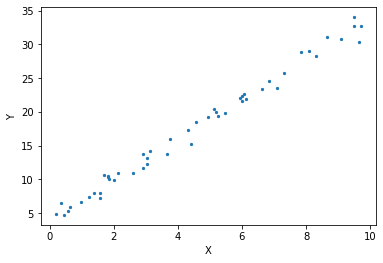

In [ ]:
# to create a reproducible experiment
np.random.seed(42)

num_sample = 50
m = 3
b = 4

# creating random samples
x = 10*np.random.rand(num_sample)
y = m*x + b + np.random.randn(num_sample)

plt.scatter(x, y, s=5)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Now, let's create the the regression line and plot it on the figure above.

In [ ]:
from ipywidgets import interact

In [ ]:
def plot_reg(m_reg, b_reg):
  num_sample = 50
  m = 3
  b = 4

  # creating random samples
  np.random.seed(0)
  x = 10*np.random.rand(num_sample)
  y = m*x + b + np.random.randn(num_sample)

  # regression line
  reg_line = m_reg*x + b_reg

  # plotting the regression line
  plt.plot(x, reg_line, c="red")
  plt.scatter(x, y, s=5)
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.show()

interact(plot_reg, m_reg=2, b_reg=6)

interactive(children=(IntSlider(value=2, description='m_reg', max=6, min=-2), IntSlider(value=6, description='…

<function __main__.plot_reg>

With the help of the interactive plot above, we are able to observe how well our regression line fits to the data we have. However, we need a mathematical foundation to evaluate the resulting line.

R-squared is a goodness-of-fit measure for regression models. It represents the proportion of variance (of `y`) that has been explained by the independent variables in the model. The coefficient $R^2$ is defined as $1 - \frac{u}{v}$, where u is the residual sum of squares $\sum_i \, (y_{true_i} - y_{pred_i})^2$ and v is the total sum of squares $\sum_i \, (y_{true_i} - \mu_{y_{true}})^2$.


![](https://i2.wp.com/statisticsbyjim.com/wp-content/uploads/2017/04/residuals-300x186.png?resize=300%2C186)


Now, let's write a function to calculate the coefficient $R^2$. This function will take two parameters, namely *y_pred* and *y_true* and then calculate the $R^2$ as described above.

In [ ]:
def r2(y_true, y_pred):
  u = sum((y_true - y_pred)**2)
  v = sum((y_true - y_true.mean())**2)

  return 1-(u/v)

Next, let's put the resulting $R^2$ on top of the existing regression plot and see how it varies as we tweak the parameters.

In [ ]:
def plot_reg_R2(m_reg, b_reg):
  num_sample = 50
  m = 3
  b = 4

  # creating random samples
  np.random.seed(0)
  x = 10*np.random.rand(num_sample)
  y = m*x + b + np.random.randn(num_sample)

  # regression line
  reg_line = m_reg*x + b_reg

  # R2 calculation
  r2_coeff = r2(y, reg_line)

  # plotting the residuals
  for i in range(len(x)):
    plt.plot((x[i], x[i]), (reg_line[i], y[i]), 'b')

  # plotting the regression line
  plt.plot(x, reg_line, c="red")
  plt.scatter(x, y, s=10, marker="s", c="black")
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.title(r"$R^2: {:.2f}$".format(r2_coeff))
  plt.show()

interact(plot_reg_R2, m_reg=2, b_reg=6)

interactive(children=(IntSlider(value=2, description='m_reg', max=6, min=-2), IntSlider(value=6, description='…

<function __main__.plot_reg_R2>

### Weather Forecasting

The dataset contains information on weather conditions recorded on each day at various weather stations around the world. Information includes precipitation, snowfall, temperatures, wind speed and whether the day included thunder storms or other poor weather conditions.

In this exercise, our goal is to predict the maximum temperature. First of all, we are going to consider the daily minimum temperature amount to predict the maximum temperature and then add further features to our input set.


In [ ]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from os.path import join

filename = "weather.csv"
df = pd.read_csv(join(path_prefix, filename))

In [ ]:
df.head()

,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,MO,DA,PRCP,DR,SPD,MAX,MIN,MEA,SNF,SND,FT,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0,NaN,42,7,1,0.04,NaN,NaN,78.0,72.0,75.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0,NaN,42,7,2,0,NaN,NaN,84.0,71.0,78.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0,NaN,42,7,3,0.1,NaN,NaN,79.0,72.0,76.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0,NaN,42,7,4,0.1,NaN,NaN,80.0,72.0,76.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0,NaN,42,7,5,0,NaN,NaN,80.0,71.0,76.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# convert Precip column to numeric
df = df[df["Precip"] != "T"]
df["Precip"] = pd.to_numeric(df["Precip"])

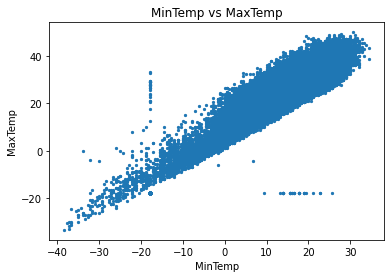

In [ ]:
df.plot.scatter(x="MinTemp", y="MaxTemp", s=5)  
plt.title("MinTemp vs MaxTemp")  
plt.xlabel("MinTemp")  
plt.ylabel("MaxTemp")  
plt.show()

### Exercise: MinTemp & Maxtemp

Instructions

- Once you are assigned to a breakout room, discuss among yourselves to decide who will be sharing the screen to collectively develop a solution. Actively participate in the group discussion.
- For your questions, you may use the `request help` button on the Zoom menu.

---

In this exercise, you are going to create a simple linear regression model to create a mapping from `MinTemp` to `MaxTemp` and plot the resulting regression model.

MaxTemp = $\alpha$*MinTemp + $\beta$

- Extract the variables from the dataframe.
- Split the dataset into two: train (80%) and test (20%) with random state set to 0.
- Create a regression model and train it with the train data.
- Obtain the resulting coefficient and the intercept values.
- Plot the regression line on the original dataframe.



In [ ]:
# your code

### Multiple Linear Regression

In simple linear regression, we have a single predictor
variable `x` which is used to model the response variable `y`. In many applications, there are more than one factor that influences the response. Multiple regression models
thus describe how a single response variable `y` depends linearly on a number of predictor variables.

<img src="https://miro.medium.com/max/3444/1*uLHXR8LKGDucpwUYHx3VaQ.png" height="200" width="420"></img>

<sub>Image obtained from https://medium.com/@manjabogicevic/multiple-linear-regression-using-python-b99754591ac0</sub>

Now, let's add further features to the model and observe how our results will change.


In [ ]:
# extracting the input and output vectors
# MinTemp: Min Temperature
# Precip: Precipitation
# DA: day (a silly variable)
features = ["MinTemp", "Precip", "DA"]
X = df[features].values  # converting to column vector
y = df['MaxTemp'].values

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
# creating the model
model = LinearRegression()  
model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [ ]:
# let's have a look at the coefficients, 
# i.e m values
coeff_df = pd.DataFrame(model.coef_, features, columns=['Coefficient'])  
coeff_df

,Coefficient
MinTemp,0.917836
Precip,-0.067535
DA,-0.003597


### Evaluation Metrics

*MSE (mean squared error):*  $\frac{1}{N}\sum_i \, (y_{true_i} - y_{pred_i})^2 \,$


*RMSE (root mean squared error):*  $\sqrt{\frac{1}{N}\sum_i \, (y_{true_i} - y_{pred_i})^2}$


*MAE (mean absolute error):* $\sum_i \, |y_{true_i} - y_{pred_i}| \,$

Since we are measuring the errors, we want to minimize these metrics.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("mse: {}".format(mse))
print("mae: {}".format(mae))
print("rmse: {}".format(rmse))

mse: 17.813236137231044
mae: 3.217325709365243
rmse: 4.220572963145057


## Regression with Other Algorithms

So far, we have been mostly dealing with classification. And as a result, We have only talked about the classification aspect of the algorithms. However, it's possible to perform regression with kNN, Decision Trees and Random Forests. All we have to do is to import the correct model name.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# create models
knn = KNeighborsRegressor(2)
dt = DecisionTreeRegressor()
rf = RandomForestRegressor(n_estimators=50)

# train as usual
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=50, n_jobs=None, oob_score=False,
                      random_state=None, verbose=0, warm_start=False)

Let's just check the performance of the random forest model.

In [ ]:
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("mse: {}".format(mse))
print("mae: {}".format(mae))
print("rmse: {}".format(rmse))

mse: 14.458316240989053
mae: 2.7786176453840215
rmse: 3.802409267949605


## Logistic Regression

In linear regression, our goal is to utilize the input variables to predict a continuous variable `y` by constructing a mapping function `f`, such that $f: x \rightarrow y$. 

In contrast, logistic regression aims to predict discrete (categorical) output variables, i.e classification. The model still constructs a mapping function `f` between input variables and the output variable. However, it further utilize the mapping function to create a decision boundry to assign labels.

![](https://cdn-images-1.medium.com/max/800/1*LFW9Z8T_vY0QmLrVD5IfwQ.png)

$f(x) \, = \, m_1*x_1 \, + ... + \, m_n*x_n \, + \, b$

$sigmoid(f(x)) \, = \, \frac{1}{1 + exp^{-f(x)}}$

Let's assume that we have a binary classification problem, we have labels 0 and 1. In addition, we already the have the slope (`m`) and intercept (`b`) parameters of the mapping function. In order to make a classification, we'll utilize a function named `sigmoid`. If we apply the sigmoid to the sum of the weighted features, i.e the mapping function `f(x)`, we get a number between 0 and 1. To make it a probability, we just need to make sure that the two cases, p(y = 1) and p(y = 0), sum to 1.

$P(y=1) = sigmoid(mx + b)$  
$P(y=1) = \frac{1}{1 + exp^{-(mx + b)}}$

$P(y=0) = 1-\frac{1}{1 + exp^{-(mx + b)}}$

Now we have an algorithm that given an instance x computes the probability P(y =
1|x). How do we make a decision? For a test instance x, we say 1 if the probability P(y = 1|x) is more than .5, and 0 otherwise.




### Sentiment Analysis

In this exercise, we are going to build a model that will determine the sentiment (neutral, positive, negative) of a given text. To this end, we have a different dataset named *train_tweets.csv* which contains 99.989 tweets.

Our target attribute is name `Sentiment`, in which 1 corresponds to positive polarity while 0 is negative polarity.

Firstly, let's read the dataset into a dataframe.

In [ ]:
filename = "train_tweets.csv"
df = pd.read_csv(join(path_prefix, filename), encoding="Latin-1")

df.head()

,ItemID,Sentiment,SentimentText
0,1,0,is so sad for my APL frie...
1,2,0,I missed the New Moon trail...
2,3,1,omg its already 7:30 :O
3,4,0,.. Omgaga. Im sooo im gunna CRy. I'...
4,5,0,i think mi bf is cheating on me!!! ...


#### Text Preprocessing

Text preprocessing is an important step for natural language processing tasks. It transforms text into a more digestible form for machine learning algorithms.

In this recitation, we are going to use a library named `nltk` to perform required preprocessing steps.


##### Special Characters

A tweets may contain various special characters due to distinct encodings across distinct countries.

Now, let's implement a function which removes any non-alphanumeric characters from the given string, i.e. tweet.

In [ ]:
import re

def remove_non_alpha(s):
  # removing non-alphanumeric chars
  s = re.sub ('[\W]+', ' ', s.lower())

  return s

In [ ]:
df["SentimentText"] = df["SentimentText"].apply(remove_non_alpha)

##### Stop Word Removal

Stop words are generally the most common words in a language.

![](https://www.researchgate.net/profile/Jennifer_Priestley/publication/318138987/figure/fig8/AS:668237603803162@1536331668931/List-of-Stopwords-in-Text-Mining-Library-of-R.png)

Now, let's remove the stop words in both training and testing data sets.

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def remove_stop_words(s):
  return " ".join([item for item in s.split() if item not in stop])

In [ ]:
df['SentimentText'] = df['SentimentText'].apply(remove_stop_words)

In [ ]:
df["SentimentText"].head()

0                                       sad apl friend
1                              missed new moon trailer
2                                     omg already 7 30
3    omgaga im sooo im gunna cry dentist since 11 s...
4                             think mi bf cheating t_t
Name: SentimentText, dtype: object

#### Exercise: Textaul Feature Vectors

Instructions

- Once you are assigned to a breakout room, discuss among yourselves to decide who will be sharing the screen to collectively develop a solution. Actively participate in the group discussion.
- For your questions, you may use the `request help` button on the Zoom menu.

---

In order to utilize the text (tweets) as inputs in our logistic regression model, we need to turn the text content into numerical feature vectors. To this end, we're going to use *bag of words* method to represent textual data as numeric vectors.

Assign a fixed integer id to each word occurring in any tweets of the training set (for instance by building a dictionary from words to integer indices).

For each tweet `i`, count the number of occurrences of each word `w` and store it in `X[i, j]` as the value of feature `j` where `j` is the index of word `w` in the dictionary.

<img height="350" src="http://uc-r.github.io/public/images/analytics/feature-engineering/bow-image.png"></img>

- Use `CountVectorizer` from Sklearn and obtain the bag-of-words representation of the tweets.

  - https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

- Split the features and the target attribute.

In [ ]:
# your code

#### Model Creation

Next, let's split the dataset into two as usual and apply a logistic regression model onto it.

In [ ]:
# your code

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# model creation
model = LogisticRegression()

In [ ]:
# build the model
model.fit(X_train, y_train)

# predict the test instances
y_preds = model.predict(X_test)

accuracy = accuracy_score(y_test, y_preds)
print("Test Accuracy: {:.2f}".format(accuracy))

Test Accuracy: 0.75
